<a href="https://colab.research.google.com/github/Yangel300/BreathIA/blob/rdlinet/Specific_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instalación de librerias

In [2]:
!pip install opendatasets
!pip install sounddevice
!pip install librosa
!pip install opendatasets
!pip install torchaudio
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [3]:
#Importacion de Librerias
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio
import soundfile as sf
from numpy import pi
import os
import pandas as pd
from itertools import product
import uuid
from tqdm import tqdm
from collections import defaultdict
import torchaudio
import torchaudio.transforms as T
import torch
import gc
import os
from sklearn.preprocessing import MultiLabelBinarizer
import time
import timeit
import opendatasets as od

#Carga de dataset

In [4]:
import kagglehub

start_time = time.time()  # Start timing
# Download latest version
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
end_time = time.time()  # End timing
print("Path to dataset files:", path)
print(f"Total execution time: {end_time - start_time:.2f} seconds")

100%|██████████| 3.69G/3.69G [00:49<00:00, 79.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vbookshelf/respiratory-sound-database/versions/2
Total execution time: 107.24 seconds


##Definir el dataframe

In [5]:
def Extract_Annotation_Data(file_name, root):
    tokens = file_name.split('_')
    recording_info = pd.DataFrame(data = [tokens], columns = ['Patient number', 'Recording index', 'Chest location','Acquisition mode','Recording equipment'])
    recording_annotations = pd.read_csv(os.path.join(root, file_name + '.txt'), names = ['Start', 'End', 'Crackles', 'Wheezes'], delimiter= '\t')
    return (recording_info, recording_annotations)

In [7]:
path_sounds = path + "/Respiratory_Sound_Database/Respiratory_Sound_Database"
filenames = [s.split('.')[0] for s in os.listdir(path = path_sounds+"/audio_and_txt_files") if '.txt' in s]

In [8]:
i_list = []
rec_annotations = []
rec_annotations_dict = {}
for s in filenames:
    (i,a) = Extract_Annotation_Data(s, path_sounds+"/audio_and_txt_files")
    i_list.append(i)
    rec_annotations.append(a)
    rec_annotations_dict[s] = a
recording_info = pd.concat(i_list, axis = 0)
recording_info.head()

,Patient number,Recording index,Chest location,Acquisition mode,Recording equipment
0,157,1b1,Pr,sc,Meditron
0,170,1b4,Ar,mc,AKGC417L
0,151,3p3,Ll,mc,AKGC417L
0,186,2b4,Pl,mc,AKGC417L
0,162,2b4,Lr,mc,AKGC417L


In [9]:
no_label_list = []
crack_list = []
wheeze_list = []
both_sym_list = []
filename_list = []
for f in filenames:
  d = rec_annotations_dict[f]
  no_labels = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 0)].index)
  n_crackles = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 0)].index)
  n_wheezes = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 1)].index)
  both_sym = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 1)].index)
  no_label_list.append(no_labels)
  crack_list.append(n_crackles)
  wheeze_list.append(n_wheezes)
  both_sym_list.append(both_sym)
  filename_list.append(f)

In [10]:
file_label_df = pd.DataFrame(data = {'filename':filename_list, 'no label':no_label_list, 'crackles only':crack_list, 'wheezes only':wheeze_list, 'crackles and wheezees':both_sym_list})
file_label_df.head()

,filename,no label,crackles only,wheezes only,crackles and wheezees
0,157_1b1_Pr_sc_Meditron,5,10,0,0
1,170_1b4_Ar_mc_AKGC417L,0,1,1,4
2,151_3p3_Ll_mc_AKGC417L,1,3,0,2
3,186_2b4_Pl_mc_AKGC417L,1,4,0,0
4,162_2b4_Lr_mc_AKGC417L,4,0,0,0


In [12]:
sympt = pd.concat([df.assign(filename=filename) for filename, df in rec_annotations_dict.items()], ignore_index=True)

sympt["Length"] = sympt["End"] - sympt["Start"]

sympt.head()

,Start,End,Crackles,Wheezes,filename,Length
0,1.3841,4.9768,1,0,157_1b1_Pr_sc_Meditron,3.5927
1,4.9768,8.1521,1,0,157_1b1_Pr_sc_Meditron,3.1753
2,8.1521,11.1440,1,0,157_1b1_Pr_sc_Meditron,2.9919
3,11.1440,13.8410,1,0,157_1b1_Pr_sc_Meditron,2.6970
4,13.8410,18.9500,1,0,157_1b1_Pr_sc_Meditron,5.1090


#Pruebas específicas

##Funciones primordiales

In [19]:
# Preprocessing
def load_audio(filename, base_path):
  audio = librosa.load(base_path+"/"+filename, mono=True)
  return audio

def resamp_audio(audio, orig_sr):
  resamp_audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=4000, res_type="fft", fix=True, scale=True)
  return resamp_audio

def trim_audio(audio, start_time, end_time):
  trimed_audio = audio[int(start_time*4000):int(end_time*4000)]
  return trimed_audio

def stft_audio(audio):
  # Calcular STFT
  n_fft = 256
  hop_length = 64
  sr = 4000
  stride = int(n_fft/4)
  stft_values = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=stride))[:,:int(2*sr/(stride))]
  return stft_values

def lin2db(stft):
  # Convertir potencia a decibelios
  S_db = librosa.power_to_db(np.abs(S), ref=np.max)
  return S_db

def low_filter(stft):
  frequencies = librosa.fft_frequencies(sr=4000, n_fft=256)
  S_filtered = stft.copy()
  # Clear base signals (<1Hz)
  S_filtered[(frequencies >= 0) & (frequencies <= 1), :] = 0
  return S_filtered

def istft_audio(stft):
  audio = librosa.istft(stft, hop_length=64)
  return audio

def normalize_audio(audio):
  audio_norm = librosa.util.normalize(audio)
  return audio_norm

def mel_spectrogram(audio):
  # Calcular espectrograma de Mel
  S = librosa.feature.melspectrogram(y=audio, sr=4000, n_fft=256, hop_length=128, n_mels=64)

  # Convertir a decibelios
  S_db = librosa.power_to_db(S, ref=np.max)

  return S_db

def plot_mel_spectrogram(spectrogram):
  plt.figure(figsize=(10, 4))
  librosa.display.specshow(spectrogram, sr=4000, hop_length=128, x_axis='time', y_axis='hz', cmap='magma')
  plt.colorbar(format='%+2.0f dB')
  plt.title('Mel Spectrogram (4 kHz)')
  plt.tight_layout()
  plt.show()

def graph_audio(audio):
  y=audio[0]
  sr=audio[1]
  y=y/np.max(np.abs(y))
  dt=y.size/sr
  plt.figure(figsize=(3.8, 2.8))
  plt.subplot()
  plt.grid()
  plt.xlim(0,dt)
  plt.ylim(-1.1,1.1)
  librosa.display.waveshow(y, sr=sr)
  plt.xlabel('tiempo [s]')
  plt.ylabel('amplitud[/]')

path_audio = path_sounds+"/audio_and_txt_files"

##Dataframe para un solo paciente

In [17]:
patient="226_1b1_Pl_sc_LittC2SE"
p_sympt=sympt[sympt["filename"]==patient]
p_sympt

,Start,End,Crackles,Wheezes,filename,Length
2999,0.036,1.207,0,0,226_1b1_Pl_sc_LittC2SE,1.171
3000,1.207,3.550,0,0,226_1b1_Pl_sc_LittC2SE,2.343
3001,3.550,5.750,1,0,226_1b1_Pl_sc_LittC2SE,2.200
3002,5.750,7.879,1,0,226_1b1_Pl_sc_LittC2SE,2.129
3003,7.879,9.836,0,0,226_1b1_Pl_sc_LittC2SE,1.957
3004,9.836,11.721,1,0,226_1b1_Pl_sc_LittC2SE,1.885
3005,11.721,13.693,1,0,226_1b1_Pl_sc_LittC2SE,1.972
3006,13.693,15.536,0,0,226_1b1_Pl_sc_LittC2SE,1.843
3007,15.536,17.493,0,0,226_1b1_Pl_sc_LittC2SE,1.957
3008,17.493,19.436,1,0,226_1b1_Pl_sc_LittC2SE,1.943


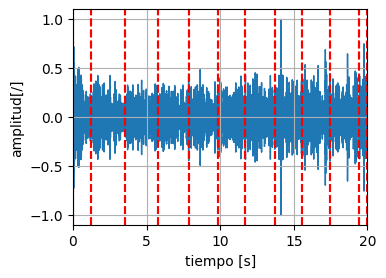

In [20]:
#Grafica en el tiempo

audio=load_audio(patient+".wav", path_audio)

graph_audio(audio)
for i in range(len(p_sympt)):
  start=p_sympt.iloc[i]["Start"]
  end=p_sympt.iloc[i]["End"]
  plt.axvline(x=start, color='r', linestyle='--')
  plt.axvline(x=end, color='r', linestyle='--')

In [21]:
#Prueba de audio
audio_resamp=resamp_audio(audio[0], audio[1])
audio_resamp=[audio_resamp,4000]
for i in range(len(p_sympt)):
  start=p_sympt.iloc[i]["Start"]
  end=p_sympt.iloc[i]["End"]
  trimmed=trim_audio(audio_resamp[0], start, end)
  trimmed=[trimmed,4000]
  #graph_audio(trimmed)
Audio(audio_resamp[0], rate=audio_resamp[1])

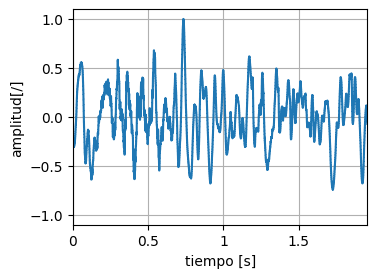

In [22]:
#Elección de fragmento específico
slice_number=4

trimmer=trim_audio(audio_resamp[0], p_sympt.iloc[slice_number]["Start"], p_sympt.iloc[slice_number]["End"])
trimmer=[trimmer,4000]
graph_audio(trimmer)

Audio(trimmer[0], rate=trimmer[1])

In [24]:
#Funciones de graficación y de gráficas de FFT
def fast_fourier_transform(y, sr):
  window = np.hanning(len(y))
  windowed_slice = y * window
  fft_data = np.fft.fft(windowed_slice)
  freqs = np.fft.fftfreq(len(fft_data), 1 / sr)
  magnitude = np.abs(fft_data)
  magnitude /= np.max(magnitude)
  return freqs, magnitude


def graph_fft1(y,sr,title="FFT",xliminf=0,xlimsup=250,yliminf=0,ylimsup=1):
  freqs, magnitude = fast_fourier_transform(y, sr)
  half_n = len(magnitude) // 2
  freqs = freqs[:half_n]
  magnitude = magnitude[:half_n]
  plt.figure(figsize=(10, 4))
  plt.plot(freqs, magnitude, color=(0.59, 0.27, 0.61))
  plt.xlabel('Frecuencia (Hz)')
  plt.ylabel('Magnitud')
  plt.title(title)
  plt.grid(True)
  plt.xlim(xliminf, xlimsup)
  plt.ylim(yliminf, ylimsup)
  plt.tight_layout()
  plt.grid(True)
  plt.show()
  return freqs, magnitude

def graph_fft2(magnitude):
  plt.figure(figsize=(10, 4))
  sr=4000
  hop_length=128
  librosa.display.specshow(librosa.amplitude_to_db(magnitude, ref=np.max), sr=4000, hop_length=hop_length, x_axis='time', y_axis='hz')
  plt.colorbar(format='%+2.0f dB')
  plt.ylim(0,1000)
  plt.title('FFT Magnitude')

#Visualización de resultados

##Sin filtro

In [31]:
Audio(trimmer[0], rate=trimmer[1])

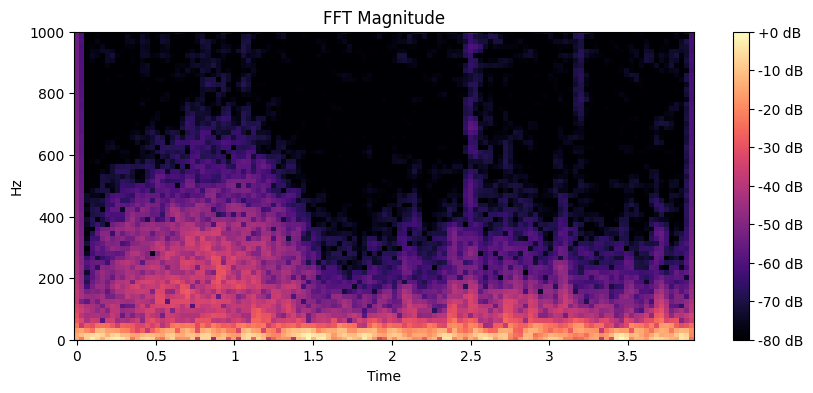

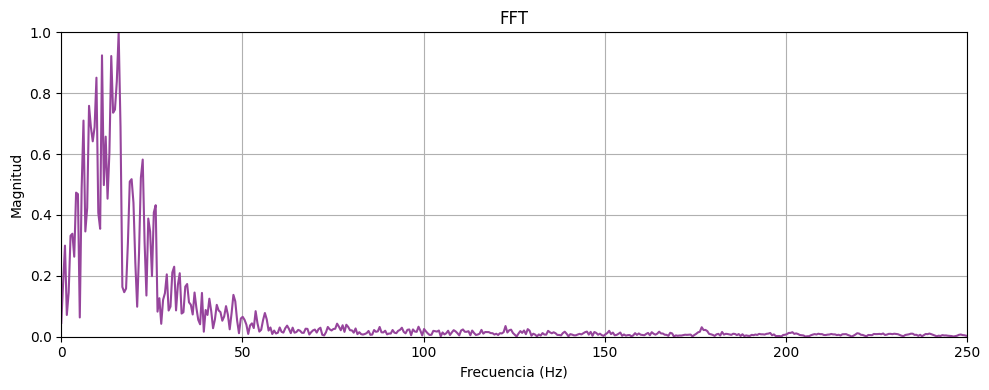

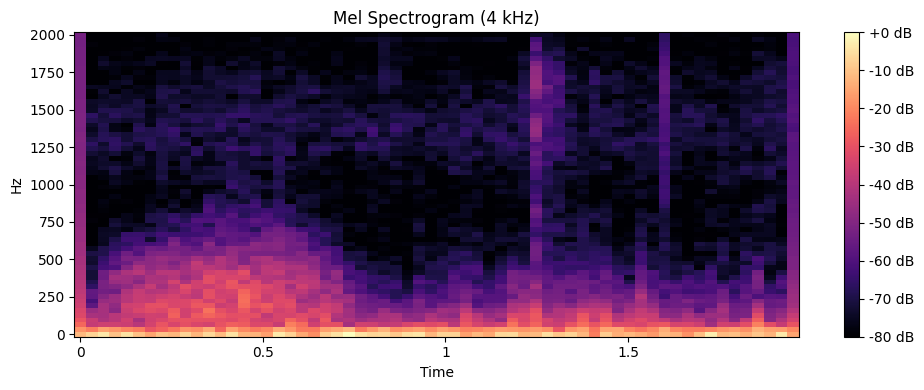

In [27]:
freq_values = stft_audio(trimmer[0])
graph_fft2(freq_values)
graph_fft1(trimmer[0],trimmer[1])
mel_spec = mel_spectrogram(trimmer[0])
plot_mel_spectrogram(mel_spec)

##Con filtro

In [32]:
filtered=low_filter(freq_values)
new_audio=istft_audio(filtered)
norm_audio=normalize_audio(new_audio)
mel_spec=mel_spectrogram(norm_audio)

In [33]:
Audio(norm_audio, rate=4000)

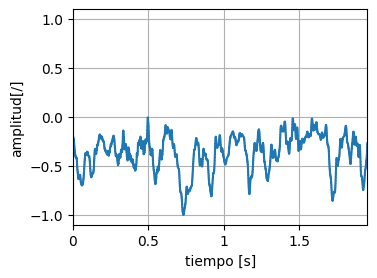

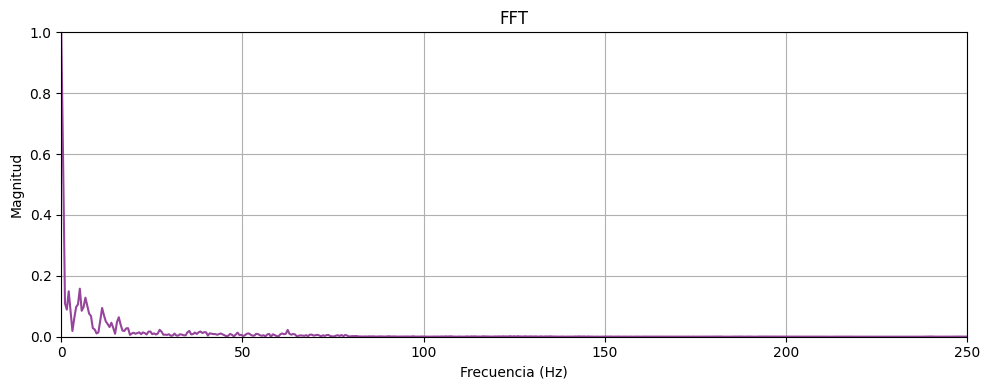

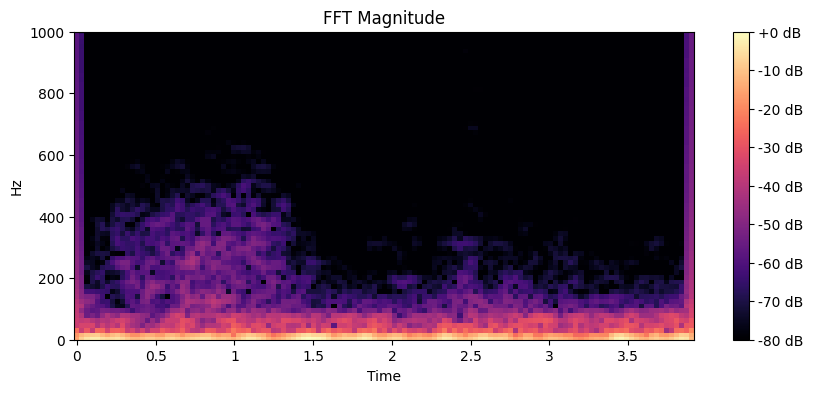

In [34]:
graph_audio([new_audio,4000])
graph_fft1(new_audio,4000)
freq_values = stft_audio(norm_audio)
graph_fft2(freq_values)